#Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#Load Dataset

In [2]:
df = pd.read_csv("household_power_consumption.csv", low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


#Parse DateTime

In [3]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

df = df.set_index('Datetime')

df = df.drop(['Date','Time'], axis=1)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
2006-12-16 17:25:00,5.36,0.436,233.63,23,0,1,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23,0,2,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23,0,1,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


#Check Missing values

In [4]:
df.isnull().sum()

Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

#Handle Missing Values

In [5]:
df = df.replace('?', np.nan)

df = df.astype(float)

df = df.fillna(method='ffill')

C:\Users\Hp\AppData\Local\Temp\ipykernel_3284\230259078.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


#Resample Time Series (Hourly)

In [6]:
energy = df['Global_active_power'].resample('H').mean()

energy.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_3284\2978351665.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  energy = df['Global_active_power'].resample('H').mean()


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

#Plot Energy Consumption

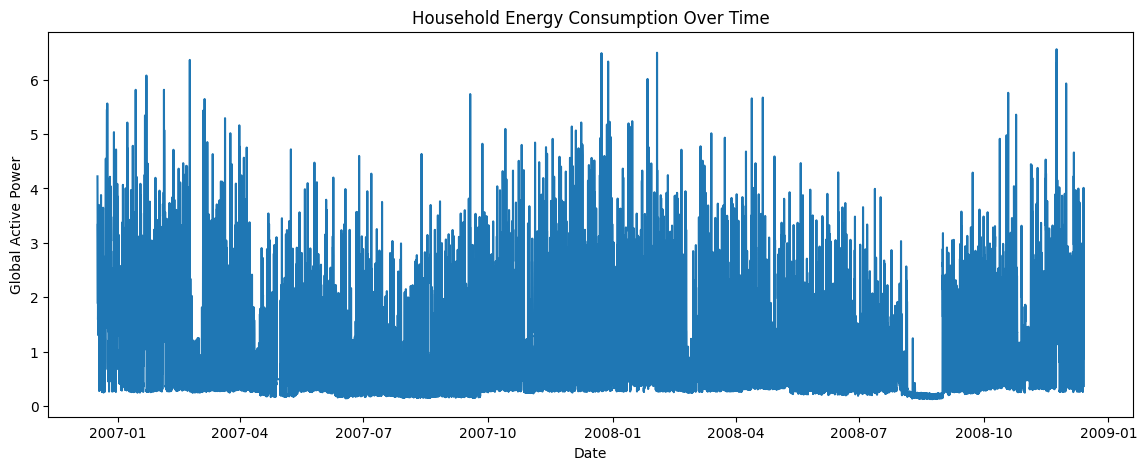

In [7]:
plt.figure(figsize=(14,5))
plt.plot(energy)
plt.title("Household Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.show()

#Feature Engineering (Time Features)

In [8]:
data = energy.to_frame()

data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['weekend'] = data['dayofweek'].isin([5,6]).astype(int)

data.head()

,Global_active_power,hour,dayofweek,month,weekend
Datetime,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,1
2006-12-16 18:00:00,3.632200,18,5,12,1
2006-12-16 19:00:00,3.400233,19,5,12,1
2006-12-16 20:00:00,3.268567,20,5,12,1
2006-12-16 21:00:00,3.056467,21,5,12,1


#Train Test Split

In [9]:
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

#ARIMA Model

In [10]:
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test['Global_active_power'], arima_forecast)

print("ARIMA MAE:", arima_mae)

ARIMA MAE: 0.7126144730454729


#Prophet Model

In [11]:
prophet_df = energy.reset_index()

prophet_df.columns = ['ds','y']

train_prophet = prophet_df[:train_size]
test_prophet = prophet_df[train_size:]

In [12]:
model = Prophet()

model.fit(train_prophet)

future = model.make_future_dataframe(periods=len(test_prophet), freq='H')

forecast = model.predict(future)

prophet_forecast = forecast['yhat'][-len(test_prophet):]

prophet_mae = mean_absolute_error(test_prophet['y'], prophet_forecast)

print("Prophet MAE:", prophet_mae)

15:25:47 - cmdstanpy - INFO - Chain [1] start processing
15:25:56 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Prophet MAE: 0.7100145362013602


#XGBoost Model

In [13]:
features = ['hour','dayofweek','month','weekend']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

In [14]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05)

xgb.fit(X_train, y_train)

xgb_forecast = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_forecast)

print("XGBoost MAE:", xgb_mae)

XGBoost MAE: 0.525615497670022


#Model Comparison

In [15]:
results = pd.DataFrame({
    "Model": ["ARIMA","Prophet","XGBoost"],
    "MAE": [arima_mae, prophet_mae, xgb_mae]
})

results

,Model,MAE
0,ARIMA,0.712614
1,Prophet,0.710015
2,XGBoost,0.525615


#Plot Actual vs Forecast

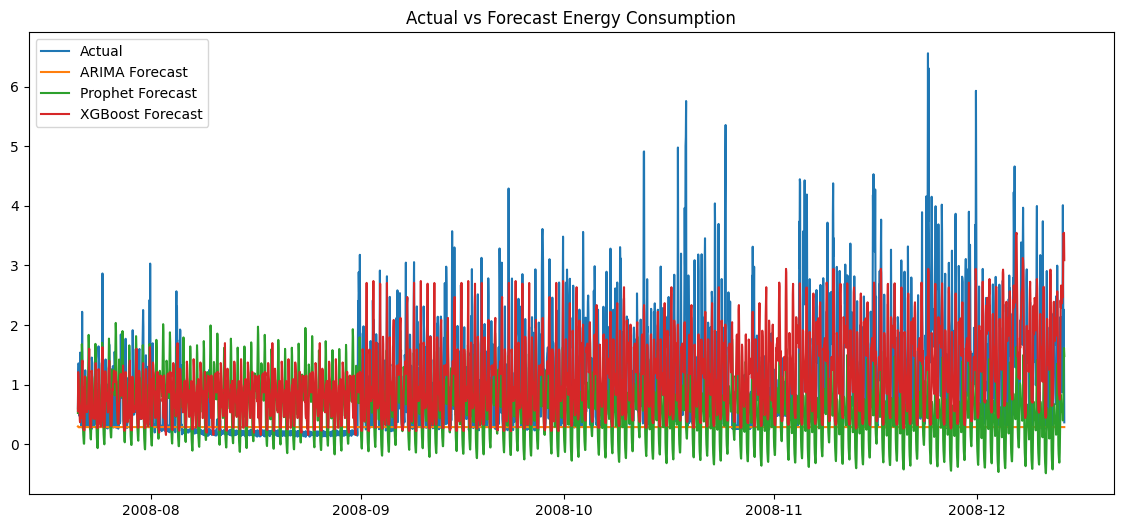

In [16]:
plt.figure(figsize=(14,6))

plt.plot(test.index, y_test, label="Actual")

plt.plot(test.index, arima_forecast, label="ARIMA Forecast")

plt.plot(test.index, prophet_forecast.values, label="Prophet Forecast")

plt.plot(test.index, xgb_forecast, label="XGBoost Forecast")

plt.legend()

plt.title("Actual vs Forecast Energy Consumption")

plt.show()

#Forecast Visualization (Best Model)

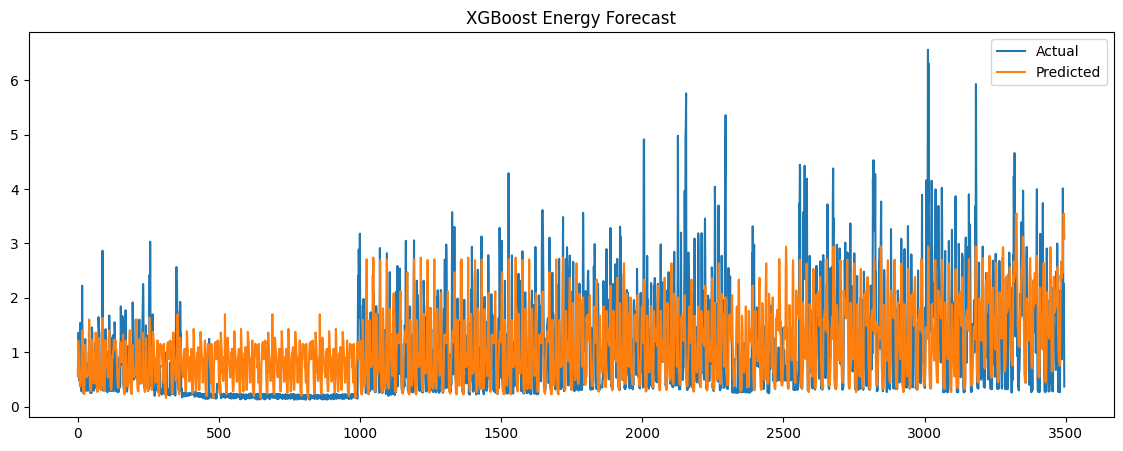

In [17]:
plt.figure(figsize=(14,5))

plt.plot(y_test.values, label="Actual")

plt.plot(xgb_forecast, label="Predicted")

plt.legend()

plt.title("XGBoost Energy Forecast")

plt.show()